In [548]:
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [549]:
df = pd.read_csv("wages_1.csv")
df.head()

,earn,height,sex,race,ed,age
0,79571.299011,73.89,male,white,16.0,49.0
1,96396.988643,66.23,female,white,16.0,62.0
2,48710.666947,63.77,female,white,16.0,33.0
3,80478.096153,63.22,female,other,16.0,95.0
4,82089.345498,63.08,female,white,17.0,43.0


METADATA
earn: Individual earnings or wage income. This variable represents the monetary compensation received by the individual.
height: Height of the individual.
sex: Categorical (male/female)
race: Categorical (white / black / hispanic / other)
ed: This variable represents the total number of years of formal schooling completed by the individual.
age: Age of the individual in years at the time of data collection.

We can see there are 4 numerical and 2 categorical values (objects)

In [550]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379 entries, 0 to 1378
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   earn    1319 non-null   float64
 1   height  1352 non-null   float64
 2   sex     1379 non-null   object 
 3   race    1379 non-null   object 
 4   ed      1356 non-null   float64
 5   age     1375 non-null   float64
dtypes: float64(4), object(2)
memory usage: 64.8+ KB


In [551]:
df.shape

(1379, 6)

In [552]:
df.describe()

,earn,height,ed,age
count,1319.000000,1352.000000,1356.000000,1375.000000
mean,32347.317932,66.557626,13.350295,45.338909
std,30966.452437,3.791617,2.434471,15.793658
min,-98.580489,57.340000,3.000000,22.000000
25%,10538.672258,63.710000,12.000000,33.000000
50%,26930.543964,66.040000,13.000000,42.000000
75%,44506.215336,69.247500,15.000000,55.000000
max,317949.127955,77.210000,18.000000,95.000000


We can see there is a negative value in "earn" category, given the type of feature this is, I will check further and discard any negative values coming from this column before continuing with the data cleaning and analysis

In [553]:
negatives = df[df["earn"] < 0]
print("Number of negative earn values:", len(negatives))

Number of negative earn values: 11


In [554]:
df = df[df["earn"] >= 0]

df.describe()

,earn,height,ed,age
count,1308.000000,1282.000000,1285.000000,1304.000000
mean,32619.707292,66.517075,13.338521,45.673313
std,30952.997947,3.805353,2.434779,15.784495
min,25.507379,57.340000,3.000000,22.000000
25%,10547.833575,63.690000,12.000000,33.750000
50%,27054.000586,66.010000,13.000000,42.500000
75%,44514.381797,69.220000,15.000000,55.000000
max,317949.127955,77.210000,18.000000,95.000000


In [555]:
#We can see there are missing values along the dataset
df.isnull().sum()

earn       0
height    26
sex        0
race       0
ed        23
age        4
dtype: int64

MISSING VALUES IMPUTER
Since there are missing values, I will plot the fill rate to visualize the missing features and proceed to impute the missing values using KNN 

In [556]:
fill_rate = 1 - df.isnull().mean()
fill_rate

earn      1.000000
height    0.980122
sex       1.000000
race      1.000000
ed        0.982416
age       0.996942
dtype: float64

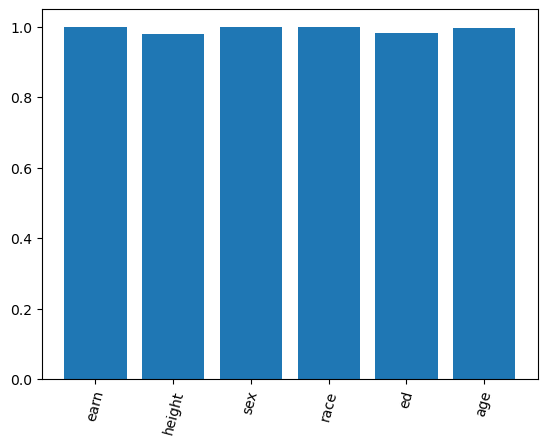

In [557]:
plt.bar(fill_rate.index, fill_rate)
plt.xticks(rotation=75)
plt.show()

In [558]:
num_cols = ["earn", "height", "ed", "age"]
imputer = KNNImputer(n_neighbors=3)
df[num_cols] = imputer.fit_transform(df[num_cols])

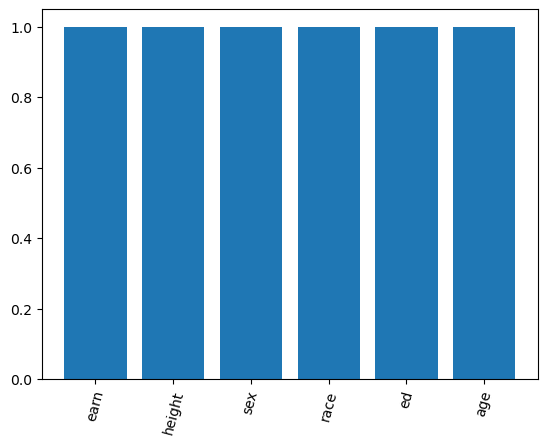

In [559]:
fill_rate = 1 - df.isnull().mean()
plt.bar(fill_rate.index, fill_rate)
plt.xticks(rotation=75)
plt.show()

CONVERTING CATEGORICAL VALUES INTO NUMERIC FORMAT

Since we will run a regression model later on. The 2 "object" categorical values need to be converted into numerical values next:

ONE-HOT ENCODING
Since the "race" column values are not ordinal I need to give each of them a true/false category column

In [560]:
df = pd.get_dummies(df, columns=["race"], drop_first=False)

In [561]:
df.head()

,earn,height,sex,ed,age,race_black,race_hispanic,race_other,race_white
0,79571.299011,73.89,male,16.0,49.0,False,False,False,True
1,96396.988643,66.23,female,16.0,62.0,False,False,False,True
2,48710.666947,63.77,female,16.0,33.0,False,False,False,True
3,80478.096153,63.22,female,16.0,95.0,False,False,True,False
4,82089.345498,63.08,female,17.0,43.0,False,False,False,True


BINARY ENCODING
I wil apply single true or false encoding to the same "sex" column so,
Male = 1
Female = 0

In [562]:
df["sex_binary"] = df["sex"].map({"male": 1, "female": 0})
df = df.drop("sex", axis=1)
df.head()

,earn,height,ed,age,race_black,race_hispanic,race_other,race_white,sex_binary
0,79571.299011,73.89,16.0,49.0,False,False,False,True,1
1,96396.988643,66.23,16.0,62.0,False,False,False,True,0
2,48710.666947,63.77,16.0,33.0,False,False,False,True,0
3,80478.096153,63.22,16.0,95.0,False,False,True,False,0
4,82089.345498,63.08,17.0,43.0,False,False,False,True,0


DATA ANALYSIS AND CLEANING

Sex distribution

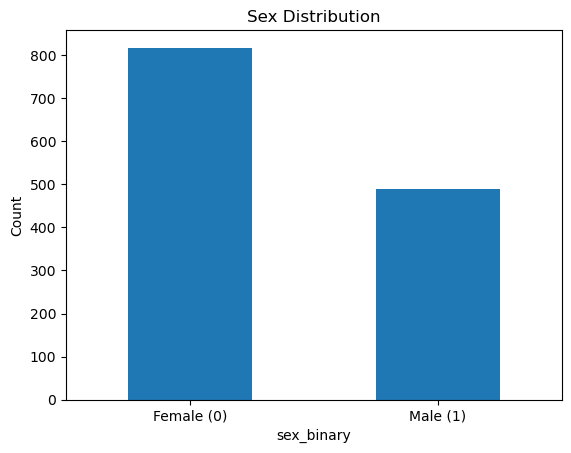

In [563]:
df["sex_binary"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Female (0)", "Male (1)"], rotation=0)
plt.title("Sex Distribution")
plt.ylabel("Count")
plt.show()

Earn Distribution

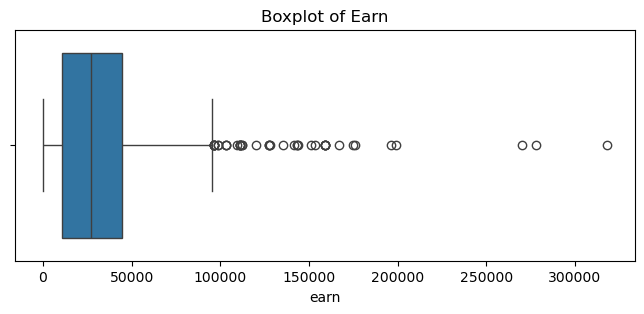

In [564]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df["earn"])
plt.title("Boxplot of Earn")
plt.show()

In [565]:
outliers = df[df["earn"] > 100000]
print("Number of earning outliers:", len(outliers))


Number of earning outliers: 36


The boxplot displays earning outliers scattered from the 100,000 figure, so I will discard them to avoid noise in the future regression model

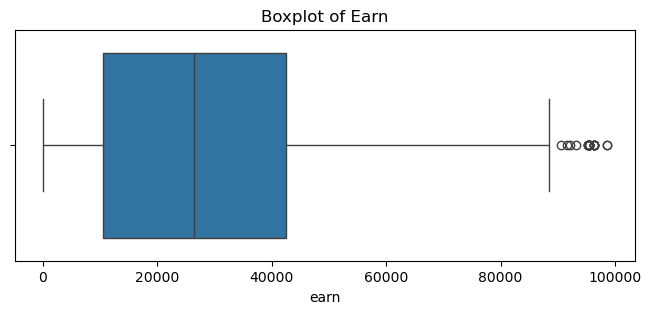

In [566]:
df = df[df["earn"] <= 100000]

plt.figure(figsize=(8,3))
sns.boxplot(x=df["earn"])
plt.title("Boxplot of Earn")
plt.show()

Races distribution

In [567]:
race_cols = [col for col in df.columns if col.startswith("race_")]

race_counts = df[race_cols].sum()
print(race_counts)

race_black        119
race_hispanic      73
race_other         27
race_white       1053
dtype: int64


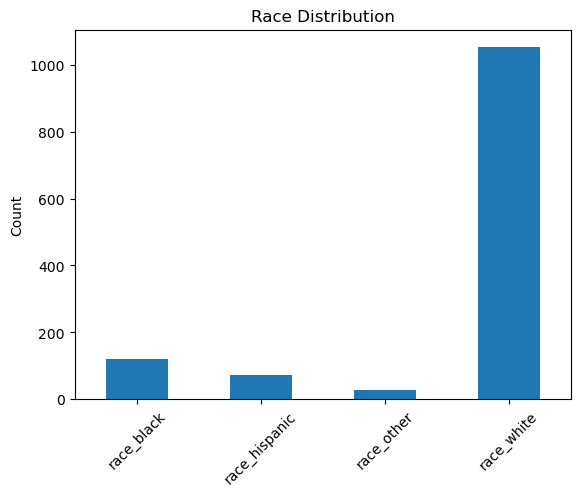

In [568]:
race_counts.plot(kind="bar")
plt.title("Race Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

The race count distribution displays a large difference between "race_white" and the other 3 categories. For the sake of the following regression exercise, I will check the earnings distribution between "other" and "hispanic" categories to confirm if grouping them in one category would be a good practice.

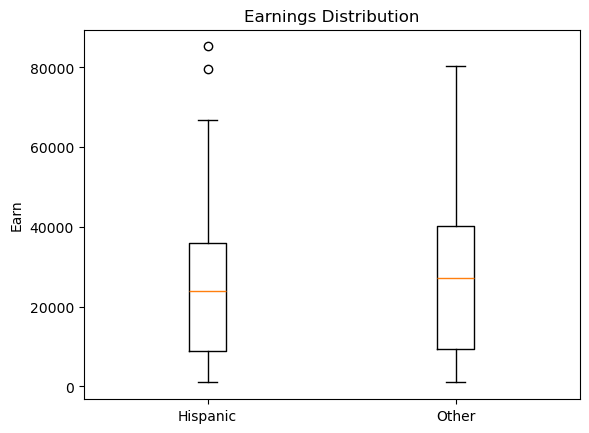

In [569]:
plt.boxplot([
    df[df["race_hispanic"] == True]["earn"],
    df[df["race_other"] == True]["earn"]
])

plt.xticks([1,2], ["Hispanic", "Other"])
plt.title("Earnings Distribution")
plt.ylabel("Earn")
plt.show()


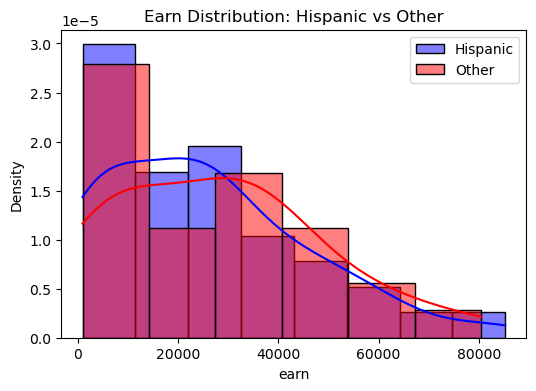

In [570]:
plt.figure(figsize=(6,4))

sns.histplot(df[df["race_hispanic"] == True]["earn"],
             color="blue", label="Hispanic", kde=True, stat="density")

sns.histplot(df[df["race_other"] == True]["earn"],
             color="red", label="Other", kde=True, stat="density")

plt.legend()
plt.title("Earn Distribution: Hispanic vs Other")
plt.show()


We can confirm that the earnings distribution is pretty close between "other" and "hispanic" races, so I will join them in one category and convert all the race categories into integers for once.

In [571]:
race_cols = [col for col in df.columns if col.startswith("race_")]
df[race_cols] = df[race_cols].astype(int)
df.head()

,earn,height,ed,age,race_black,race_hispanic,race_other,race_white,sex_binary
0,79571.299011,73.89,16.0,49.0,0,0,0,1,1
1,96396.988643,66.23,16.0,62.0,0,0,0,1,0
2,48710.666947,63.77,16.0,33.0,0,0,0,1,0
3,80478.096153,63.22,16.0,95.0,0,0,1,0,0
4,82089.345498,63.08,17.0,43.0,0,0,0,1,0


In [572]:
df["race_others"] = ((df["race_hispanic"] + df["race_other"]) > 0)
df = df.drop(columns=["race_hispanic", "race_other"])

df.head()

,earn,height,ed,age,race_black,race_white,sex_binary,race_others
0,79571.299011,73.89,16.0,49.0,0,1,1,False
1,96396.988643,66.23,16.0,62.0,0,1,0,False
2,48710.666947,63.77,16.0,33.0,0,1,0,False
3,80478.096153,63.22,16.0,95.0,0,0,0,True
4,82089.345498,63.08,17.0,43.0,0,1,0,False


Correlation Analysis

In [573]:
df["race_group"] = np.select(
    [
        df["race_black"] == 1,
        df["race_white"] == 1,
        df["race_others"] == 1
    ],
    ["Black", "White", "Others"],
    default="Unknown")


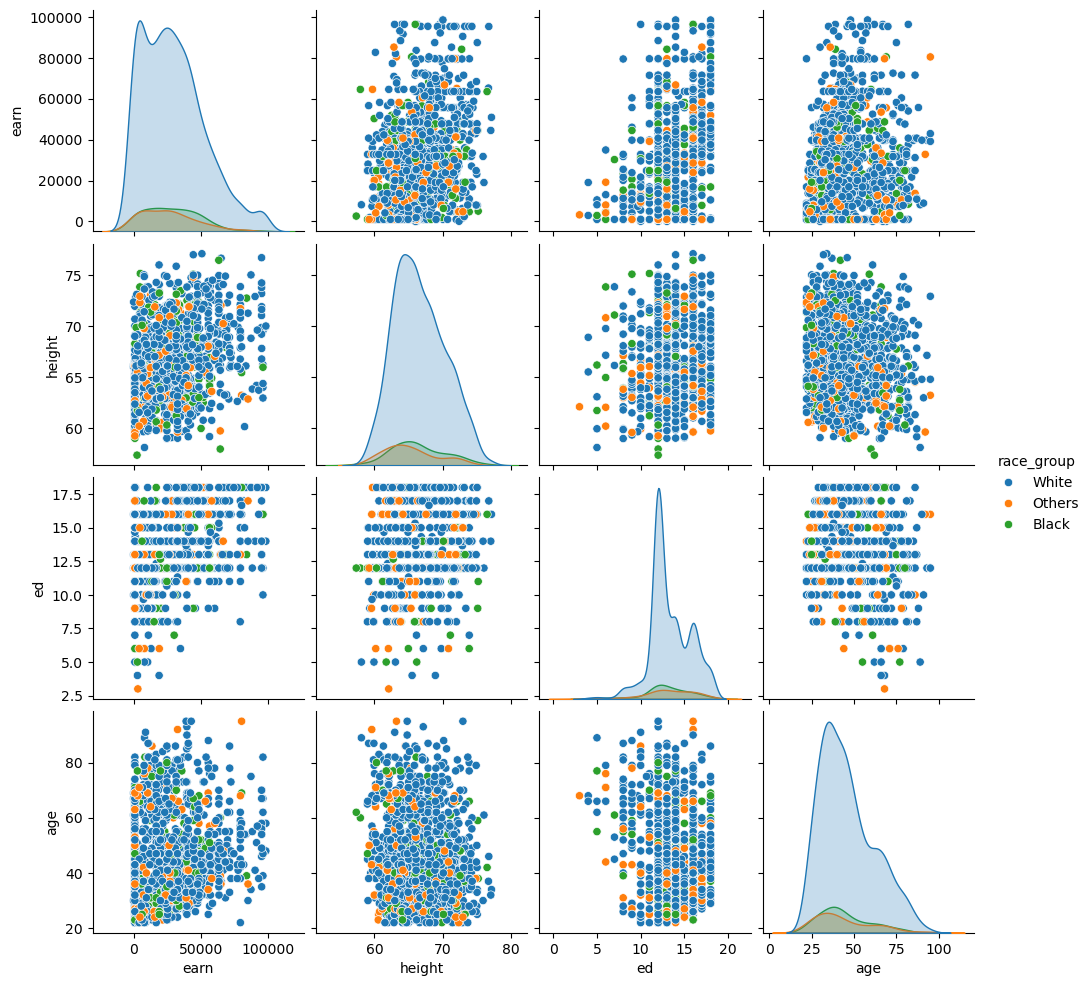

In [574]:
sns.pairplot(df[cont_cols + ["race_group"]],
             hue="race_group",
             diag_kind="kde")
plt.show()


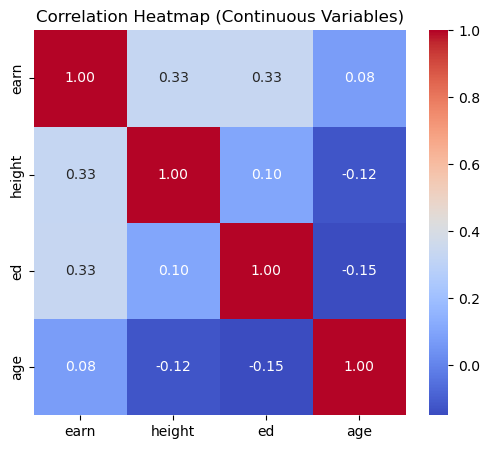

In [575]:
cont_cols = ["earn", "height", "ed", "age"]

corr = df[cont_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Continuous Variables)")
plt.show()

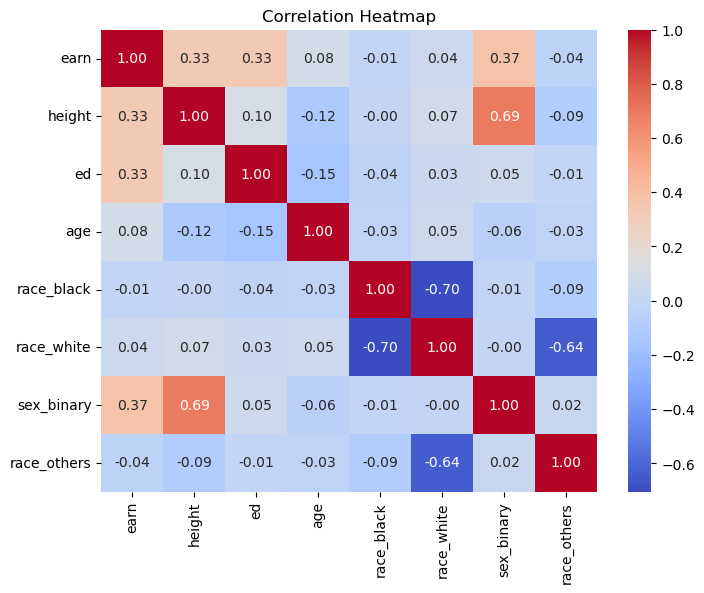

In [576]:
df = df.drop(columns=["race_group"], errors="ignore")

corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

Correlation insights:
The exploratory analysis reveals several meaningful relationships among the variables. Earnings show a moderate positive correlation with both education (r ≈ 0.33) and height (r ≈ 0.33), suggesting that higher educational attainment is associated with higher income, while height may capture indirect socioeconomic or demographic effects. Age, however, exhibits only a weak correlation with earnings (r ≈ 0.08). Overall, the relationships appear moderate rather than strong, implying that earnings are likely influenced by multiple interacting factors rather than a single dominant predictor

Conclusion for ML Process:
Since there are few features and no dominant or strong features related to our target "earn" I will proceed to run the ML regression including al of the features

APPLYING MACHINE LEARNING
Our chosen target (Y) is"earn".

LINEAR REGRESSION

In [627]:
X = df.drop("earn", axis=1)
y = df["earn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [628]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()


In [629]:
model.fit(X_train, y_train)


LinearRegression()

In [630]:
y_pred = model.predict(X_test)

In [631]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
from sklearn.model_selection import cross_val_score

linear_train_r2 = r2_score(y_train, y_train_pred)
linear_test_r2  = r2_score(y_test, y_test_pred)
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2")

linear_rcv = cv_scores.mean()

print("Linear - Train R²:", linear_train_r2)
print("Linear - Test R²:", linear_test_r2)
print("Linear - CV R²:", linear_rcv)

Linear - Train R²: 0.47903127159151193
Linear - Test R²: 0.22252084907281455
Linear - CV R²: 0.7212543465311081


Since the first attempt score is not enough. I will proceed to apply logaritmic fit to my target "earn"

In [582]:
df["log_earn"] = np.log(df["earn"])
df.head()

,earn,height,ed,age,race_black,race_white,sex_binary,race_others,log_earn
0,79571.299011,73.89,16.0,49.0,0,1,1,False,11.284409
1,96396.988643,66.23,16.0,62.0,0,1,0,False,11.476230
2,48710.666947,63.77,16.0,33.0,0,1,0,False,10.793653
3,80478.096153,63.22,16.0,95.0,0,0,0,True,11.295740
4,82089.345498,63.08,17.0,43.0,0,1,0,False,11.315564


In [583]:
X = df.drop(["earn", "log_earn"], axis=1)
y = df["log_earn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42)

In [584]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [585]:
model.fit(X_train, y_train)

LinearRegression()

In [586]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

In [587]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Linear - LOG Train R²:", train_r2)
print("Linear - LOG Test  R²:", test_r2)

Linear - LOG Train R²: 0.20804029844038874
Linear - LOG Test  R²: 0.16286687410061673


After creating "log_earn" the second linear regression attempt score was even lower. Now I'll apply standard scaler into the X features to do a final linear regression run

STANDARD SCALER WITH PIPELINE FOR LINEAR REGRESSION

In [588]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [589]:
y = df["earn"]
X = df.drop(columns=["earn", "log_earn"], errors="ignore")

In [590]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [591]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())])

In [592]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [593]:
y_train_pred = pipe.predict(X_train)
y_test_pred  = pipe.predict(X_test)

In [594]:
from sklearn.model_selection import cross_val_score
linear_pipeline_train_r2 = r2_score(y_train, y_train_pred)
linear_pipeline_test_r2  = r2_score(y_test, y_test_pred)
cv_scores = cross_val_score(
    pipe,       
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

linear_pipeline_cv = cv_scores.mean()

print("Standard Scaler - Train R²:", linear_pipeline_train_r2)
print("Standard Scaler - Test R²:", linear_pipeline_test_r2)
print("Standard Scaler - CV R²:", linear_pipeline_cv)

Standard Scaler - Train R²: 0.26915453380341814
Standard Scaler - Test R²: 0.2542416604001262
Standard Scaler - CV R²: 0.25332147669618427


After trying out the linear regression with "earn" as a target, applying standard scaler + pipeline, I see I got the same score as the first attempt. I can conclude that if I standard-scaled the X features, these won't be sensitive to the Linear regression results. Therefore, I'll apply it to run other regression models.

GRID SEARCH WITH RIDGE AND LASSO REGULARISATION

In [595]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

from sklearn.metrics import r2_score, mean_squared_error

In [596]:
y = df["earn"]
X = df.drop(columns=["earn", "log_earn"], errors="ignore")

In [597]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())])

In [598]:
param_grid = [
    {"model": [Ridge()],
    "model__alpha": [0.01, 0.1, 1, 10, 100]},
    {"model": [Lasso(max_iter=20000)],
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]}]

Applying the Grid Search (CV)

In [599]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1)

grid.fit(X_train, y_train)

print("Best model:", grid.best_estimator_.named_steps["model"])
print("Best params:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

Best model: Ridge(alpha=10)
Best params: {'model': Ridge(), 'model__alpha': 10}
Best CV R²: 0.25341333428183754


In [600]:
best_model = grid.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

GridSearch_train_r2 = r2_score(y_train, y_train_pred)
GridSearch_test_r2  = r2_score(y_test, y_test_pred)

print("Grid Search - Train R²:", GridSearch_train_r2)
print("Grid Search - Test  R²:", GridSearch_test_r2)

Grid Search - Train R²: 0.2691320906666239
Grid Search - Test  R²: 0.254225850933091


This applied Grid search displays a not satisfactory score for predicting performance still, although we could say that the model is stable since there is minimal overfitting.

RANDOM FOREST REGRESSION

In [601]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [602]:
y = df["earn"]
X = df.drop(columns=["earn", "log_earn"], errors="ignore")

In [603]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [604]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1)

In [605]:
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred  = rf.predict(X_test)

In [607]:
randomForest_train_r2 = r2_score(y_train, y_train_pred)
randomForest_test_r2  = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Random Forest - Train R²:", randomForest_train_r2)
print("Random Forest - Test  R²:", randomForest_test_r2)

Random Forest - Train R²: 0.8921311536675255
Random Forest - Test  R²: 0.2200850520859794


After applying the random forest regression, I got an overly high train score, which suggests overfitting in the model. The predictive model is not balanced and satisfactory for the exercise.

GRADIENT BOOSTING MODEL

In [608]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [609]:
y = df["earn"]
X = df.drop(columns=["earn", "log_earn"], errors="ignore")

In [610]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [611]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

In [612]:
gb.fit(X_train, y_train)
y_train_pred = gb.predict(X_train)
y_test_pred  = gb.predict(X_test)

In [613]:
GradientBoosting_train_r2 = r2_score(y_train, y_train_pred)
GradientBoosting_test_r2  = r2_score(y_test, y_test_pred)
gb_r2 = r2_score(y_test, y_test_pred)

print("Gradient Boosting - R²:", gb_r2)
print("Gradient Boosting - Train R²:", GradientBoosting_train_r2)
print("Gradient Boosting - Test  R²:", GradientBoosting_test_r2)

Gradient Boosting - R²: 0.3162930539384581
Gradient Boosting - Train R²: 0.6160204004550938
Gradient Boosting - Test  R²: 0.3162930539384581


After doing the Gradient boosting model, I've got the best score so far, although is still not satisfactory and we can see a little of overfitting when comparing train vs test scores

K-NEAREST NEIGHBOUR

In [614]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [615]:
y = df["earn"]
X = df.drop(columns=["earn", "log_earn"], errors="ignore")

In [616]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [617]:
knn = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(
        n_neighbors=5,
        weights="uniform"))])

In [618]:
knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', KNeighborsRegressor())])

In [619]:
y_train_pred = knn.predict(X_train)
y_test_pred  = knn.predict(X_test)

In [620]:
Knn_train_r2 = r2_score(y_train, y_train_pred)
Knn_test_r2  = r2_score(y_test, y_test_pred)
knn_r2 = r2_score(y_test, y_test_pred)  

print("KNN - R²:", knn_r2)
print("KNN - Train R²:", Knn_train_r2)
print("KNN - Test R²:", Knn_test_r2)

KNN - R²: 0.22252084907281455
KNN - Train R²: 0.47903127159151193
KNN - Test R²: 0.22252084907281455


After running Knn model, I see the score is still unsatisfactory and there is a light overfitting as well.

SCORES COMPARISON FOR CONCLUSIONS

In [632]:
results = []
results.append({
    "Model": "Linear Regression",
    "Train R²": linear_train_r2,
    "Test R²": linear_test_r2})


In [633]:
results.append({
    "Model": "Ridge (GridSearch)",
    "Train R²": GridSearch_train_r2,
    "Test R²": GridSearch_test_r2})

In [634]:
results.append({
    "Model": "Random Forest",
    "Train R²": randomForest_train_r2,
    "Test R²": randomForest_test_r2})

In [635]:
results.append({
    "Model": "Gradient Boosting",
    "Train R²": GradientBoosting_train_r2,
    "Test R²": GradientBoosting_test_r2})


In [636]:
results.append({
    "Model": "KNN",
    "Train R²": Knn_train_r2,
    "Test R²": Knn_test_r2})

In [637]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="Test R²", ascending=False)

results_df


,Model,Train R²,Test R²
3,Gradient Boosting,0.616020,0.316293
1,Ridge (GridSearch),0.269132,0.254226
0,Linear Regression,0.479031,0.222521
4,KNN,0.479031,0.222521
2,Random Forest,0.892131,0.220085


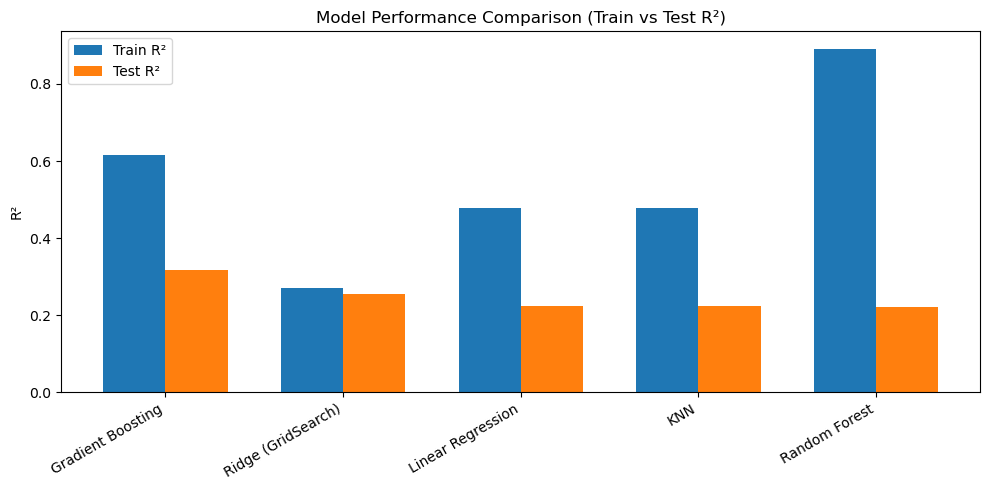

In [639]:
import matplotlib.pyplot as plt
import numpy as np

df_plot = results_df.copy()

x = np.arange(len(df_plot["Model"]))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, df_plot["Train R²"], width, label="Train R²")
plt.bar(x + width/2, df_plot["Test R²"], width, label="Test R²")

plt.xticks(x, df_plot["Model"], rotation=30, ha="right")
plt.ylabel("R²")
plt.title("Model Performance Comparison (Train vs Test R²)")
plt.legend()
plt.tight_layout()
plt.show()

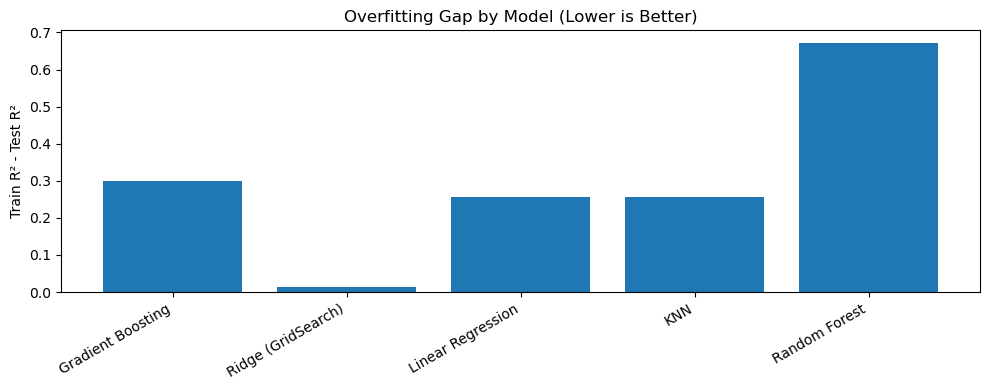

In [640]:
import matplotlib.pyplot as plt

df_plot = results_df.copy()
df_plot["Overfit Gap"] = df_plot["Train R²"] - df_plot["Test R²"]

plt.figure(figsize=(10, 4))
plt.bar(df_plot["Model"], df_plot["Overfit Gap"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Train R² - Test R²")
plt.title("Overfitting Gap by Model (Lower is Better)")
plt.tight_layout()
plt.show()

ML CONCLUSIONS
Among all evaluated models, Gradient Boosting delivered the strongest predictive performance (Test R² ≈ 0.32). However, the noticeable gap between training and test performance suggests moderate overfitting, meaning the model may not generalize perfectly to unseen data.
Ridge Regression provided the most stable and balanced results, with similar train and test scores (Test R² ≈ 0.25), reflecting better generalization but lower overall predictive strength.
Linear Regression and KNN showed weaker and nearly identical performance (Test R² ≈ 0.22), indicating that simpler linear or distance-based models are limited in explaining income variability using the current feature set.

ABOUTH THE DATASET
Overall, This suggests that earnings are driven by additional factors not currently included in the dataset. Future improvements should focus on incorporating richer socioeconomic, professional, or experience-related variables rather than solely relying on more complex algorithms.